In [10]:
!pip install geomloss

import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation")  # <<< updated path here to refer to the implementation of OT-Impute and other imputation methods
import utils
import Inject_Missing_Values
import Updated_OT
import imputers
import imputers_fullyActive



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt
from imputers import OTimputer
import os
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings("ignore")

In [12]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Starting the experiment...")

# Function to generate missingness
def generate_missingness(X, rate, mechanism="MCAR"):
    X_missing = X.copy()
    n_samples, n_features = X.shape
    n_total_entries = n_samples * n_features
    n_missing = int(rate * n_total_entries)
    rng = np.random.default_rng(42)

    if mechanism == "MCAR":
        missing_indices = (
            rng.integers(0, n_samples, n_missing),
            rng.integers(0, n_features, n_missing)
        )
    elif mechanism == "MAR":
        dep_col = rng.integers(0, n_features)
        prob = MinMaxScaler().fit_transform(X.iloc[:, [dep_col]]).flatten()
        missing_indices = np.where(rng.random(n_total_entries).reshape(n_samples, n_features) < prob.reshape(-1, 1))
    elif mechanism == "MNAR":
        prob = MinMaxScaler().fit_transform(X).flatten()
        missing_indices = np.where(rng.random(n_total_entries).reshape(n_samples, n_features) < prob.reshape(n_samples, n_features))
    
    for row_idx, col_idx in zip(*missing_indices):
        X_missing.iat[row_idx, col_idx] = np.nan

    return X_missing

# Safe mean and std functions
def safe_nanmean(arr, axis=0):
    if np.all(np.isnan(arr)):
        return np.nan
    return np.nanmean(arr, axis=axis)

def safe_nanstd(arr, axis=0):
    if np.all(np.isnan(arr)):
        return np.nan
    return np.nanstd(arr, axis=axis)

# Datasets and settings
datasets = {
    "Adult": fetch_openml(name="adult", version=2, as_frame=True).data,
    "Cancer": fetch_openml(name="breast-w", version=1, as_frame=True).data,
    "Credit": fetch_openml(name="credit-g", version=1, as_frame=True).data,
    "Wine": fetch_openml(name="wine", version=1, as_frame=True).data,
    "Disease": fetch_openml(name="diabetes", version=1, as_frame=True).data
}
missingness_types = ["MCAR", "MAR", "MNAR"]
records = []

print("Datasets loaded successfully.")

# Preprocess datasets and calculate Brier scores
for dataset_name, X_full in datasets.items():
    print(f"Processing dataset: {dataset_name}")
    
    # Preprocess the dataset
    for col in X_full.select_dtypes(include=['category', 'object']).columns:
        X_full[col] = X_full[col].astype('category').cat.codes
    scaler = MinMaxScaler()
    X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)
    X_clean = X_full.copy()

    # Calculate the range of values for normalization
    value_range = np.nanmax(X_clean.values) - np.nanmin(X_clean.values)

    for missingness in missingness_types:
        print(f"  Running missingness type: {missingness}")
        
        # Generate missing data
        X_missing = generate_missingness(X_clean, rate=0.3, mechanism=missingness)

        # Compute confidence from multiple OTimputer runs
        missing_mask = X_missing.isna()
        imputed_runs = []
        print("  Imputing missing values...")
        for _ in range(4):
            X_missing_tensor = torch.tensor(X_missing.values, dtype=torch.float64)
            ot_imputer = OTimputer(niter=100, batchsize=128)
            X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
            imputed_runs.append(X_imputed_tensor.detach().numpy())

        imputed_stack = np.stack(imputed_runs, axis=0)
        imputed_mean = safe_nanmean(imputed_stack, axis=0)
        imputed_std = safe_nanstd(imputed_stack, axis=0)

        # Exponential decay for confidence
        predicted_probs = np.exp(-imputed_std)

        # Precompute the flattened confidence array only once
        flattened_probs = predicted_probs[missing_mask.values].flatten()

        # Calculate Brier score using normalized error
        brier_scores = []
        missing_positions = np.argwhere(missing_mask.values)
        for idx, (r, c) in enumerate(missing_positions):
            pred = imputed_mean[r, c]
            true = X_clean.values[r, c]
            error = abs(pred - true) / value_range
            y_i = 1 if error <= 0.3 else 0
            prob = flattened_probs[idx] if idx < len(flattened_probs) else 0.5
            brier = (prob - y_i) ** 2
            brier_scores.append(brier)

        # Record the average Brier score for the dataset and missingness type
        brier_score_avg = np.nanmean(brier_scores)
        records.append({
            "Dataset": dataset_name,
            "Missingness": missingness,
            "BrierScore": brier_score_avg
        })
        
        # Print the calculated Brier score
        print(f"  Brier Score for {dataset_name} ({missingness}): {brier_score_avg:.4f}")

print("All datasets processed.")

Starting the experiment...
Datasets loaded successfully.
Processing dataset: Adult
  Running missingness type: MCAR
  Imputing missing values...
  Brier Score for Adult (MCAR): 0.1678
  Running missingness type: MAR
  Imputing missing values...
  Brier Score for Adult (MAR): 0.1714
  Running missingness type: MNAR
  Imputing missing values...
  Brier Score for Adult (MNAR): 0.5086
Processing dataset: Cancer
  Running missingness type: MCAR
  Imputing missing values...
  Brier Score for Cancer (MCAR): 0.1562
  Running missingness type: MAR
  Imputing missing values...
  Brier Score for Cancer (MAR): 0.2968
  Running missingness type: MNAR
  Imputing missing values...
  Brier Score for Cancer (MNAR): 0.5794
Processing dataset: Credit
  Running missingness type: MCAR
  Imputing missing values...
  Brier Score for Credit (MCAR): 0.2309
  Running missingness type: MAR
  Imputing missing values...
  Brier Score for Credit (MAR): 0.2585
  Running missingness type: MNAR
  Imputing missing valu

In [14]:
# Convert the list of records to a DataFrame
agg_df = pd.DataFrame(records)

# Optional: sort and format for plotting
agg_df['Missingness'] = pd.Categorical(agg_df['Missingness'], categories=['MCAR', 'MAR', 'MNAR'], ordered=True)
agg_df = agg_df.sort_values(['Dataset', 'Missingness']).reset_index(drop=True)

# View the resulting DataFrame
print(agg_df)


    Dataset Missingness  BrierScore
0     Adult        MCAR    0.167783
1     Adult         MAR    0.171369
2     Adult        MNAR    0.508595
3    Cancer        MCAR    0.156217
4    Cancer         MAR    0.296829
5    Cancer        MNAR    0.579384
6    Credit        MCAR    0.230852
7    Credit         MAR    0.258549
8    Credit        MNAR    0.683218
9   Disease        MCAR    0.054147
10  Disease         MAR    0.073885
11  Disease        MNAR    0.105370
12     Wine        MCAR    0.042895
13     Wine         MAR    0.072799
14     Wine        MNAR    0.141898


Plotting results...
Plot saved as brier_score_mean_std.pdf


<Figure size 1400x700 with 0 Axes>

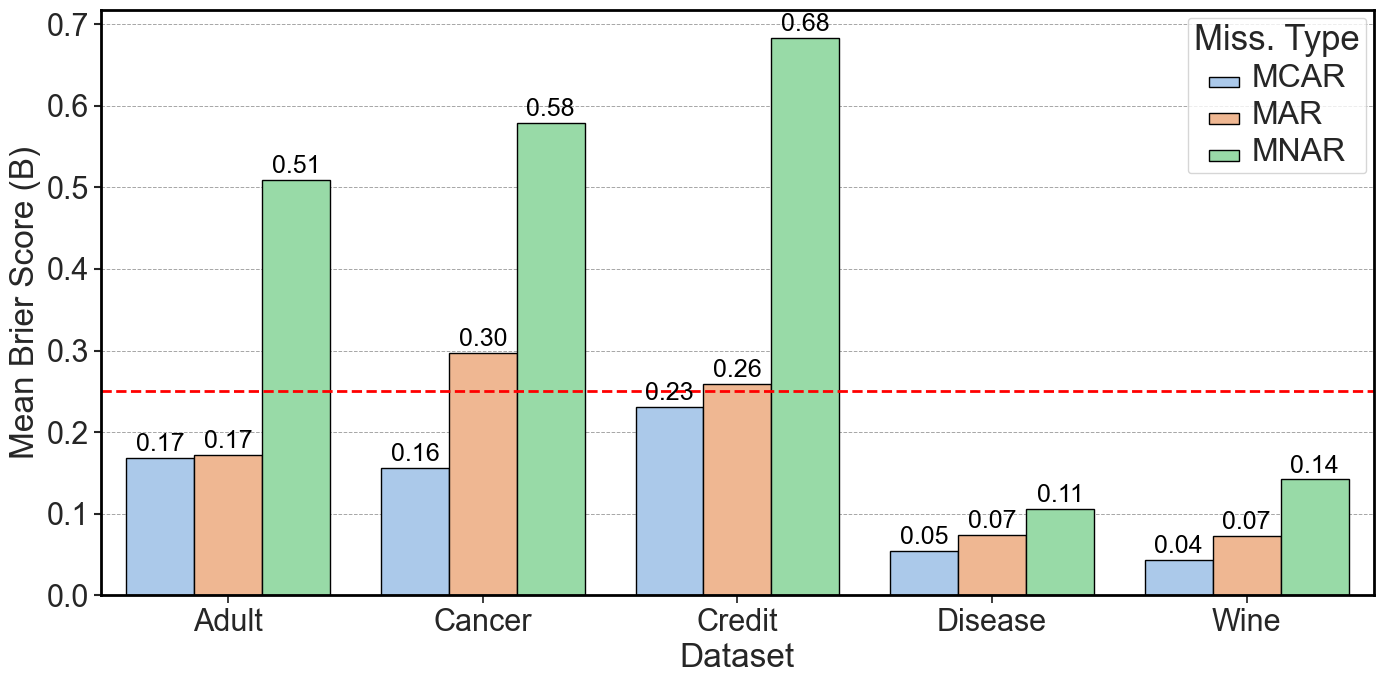

Experiment completed successfully.


In [18]:
# Plotting
print("Plotting results...")

# Custom font sizes
x_label_fontsize = 24
y_label_fontsize = 24
x_tick_fontsize = 22
y_tick_fontsize = 22
legend_title_fontsize = 25
legend_label_fontsize = 23
bar_number_fontsize = 18

# Sort the data to ensure the order: MCAR, MAR, MNAR
agg_df['Missingness'] = pd.Categorical(agg_df['Missingness'], categories=['MCAR', 'MAR', 'MNAR'], ordered=True)
agg_df = agg_df.sort_values(['Dataset', 'Missingness'])

# Plot grouped barplot with adjusted width and height
plt.figure(figsize=(14, 7))  # Width is twice the height
sns.set(style="ticks")  # Use 'ticks' style to enable more control over grid lines
g = sns.catplot(
    data=agg_df, kind="bar",
    x="Dataset", y="BrierScore", hue="Missingness",
    height=7, aspect=2, palette="pastel", legend_out=False,
    edgecolor="black"
)

# Customize font sizes for axis labels
g.set_xlabels("Dataset", fontsize=x_label_fontsize)
g.set_ylabels("Mean Brier Score (B)", fontsize=y_label_fontsize)

# Adding the legend with the correct title and label font sizes
legend = g._legend  # Access the legend directly from the FacetGrid
legend.set_title("Miss. Type")
legend.get_title().set_fontsize(legend_title_fontsize)  # Correctly set the title font size
for text in legend.get_texts():
    text.set_fontsize(legend_label_fontsize)  # Set the label font size

# Adding value labels on top of each bar and the red dotted line at 0.25
for ax in g.axes.flat:
    # Draw a red horizontal line at Brier score = 0.25 (random baseline)
    ax.axhline(y=0.25, color='red', linestyle='--', linewidth=2, label='Random Guess (0.25)')
    
    for p, (_, row) in zip(ax.patches, agg_df.iterrows()):
        height = p.get_height()
        # Add value label on top of the bar
        ax.annotate(
            f'{height:.2f}', 
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='baseline', fontsize=bar_number_fontsize, color='black', xytext=(0, 5),
            textcoords='offset points'
        )

    # Set font size for X and Y axis tick labels
    ax.tick_params(axis='x', labelsize=x_tick_fontsize)
    ax.tick_params(axis='y', labelsize=y_tick_fontsize)

    # Adding dark black borders on all four sides
    for spine_name, spine in ax.spines.items():
        spine.set_visible(True)       # Ensure the spine is visible
        spine.set_color('black')      # Set dark black color
        spine.set_linewidth(2)        # Set the border thickness

    # Explicitly enable horizontal grid lines on the Y-axis
    ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Adding small tick marks on the y-axis
for ax in g.axes.flat:
    ax.yaxis.set_tick_params(width=1.5, length=5)

# Save the plot as PDF
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\brier_score_mean_std.pdf", format="pdf", bbox_inches="tight")
print("Plot saved as brier_score_mean_std.pdf")
plt.show()

print("Experiment completed successfully.")